# Exploratory Data Analysis on Bike Data

### Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### Dataframe Loading

In [5]:
df = pd.read_csv("../data/SeoulBikeData.csv", encoding="latin1")

In [6]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [7]:
df.tail()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [9]:
df.isnull().sum()

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')

### Descriptive Statistics

In [12]:
df.describe()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


### Distributions of features with numeric values

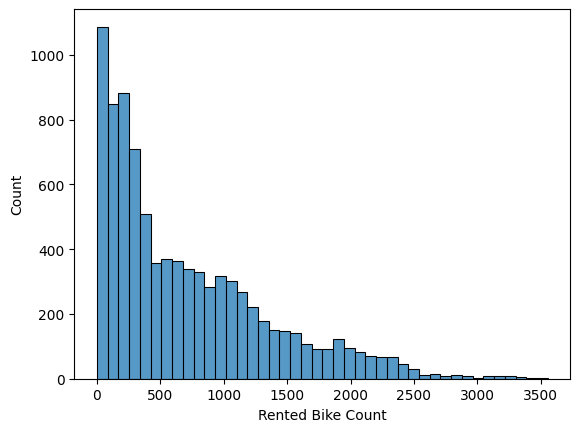

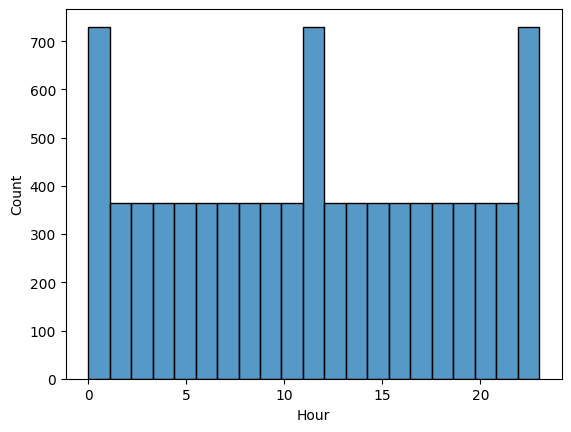

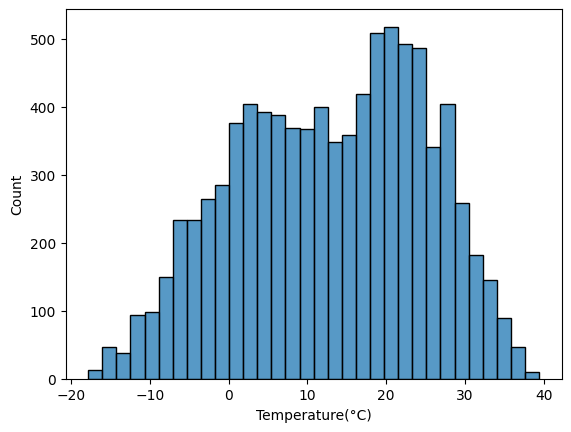

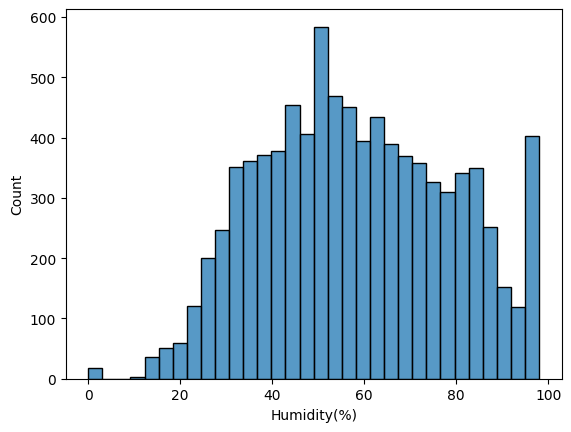

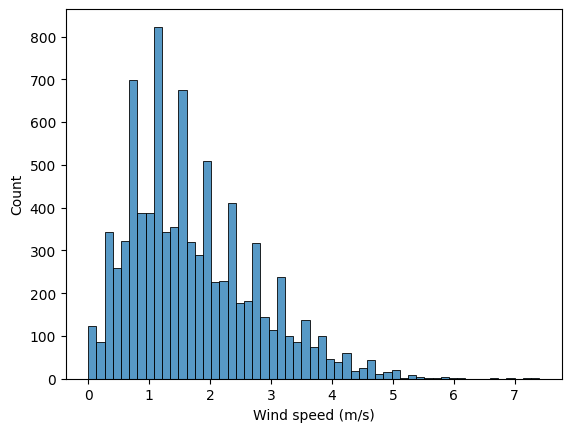

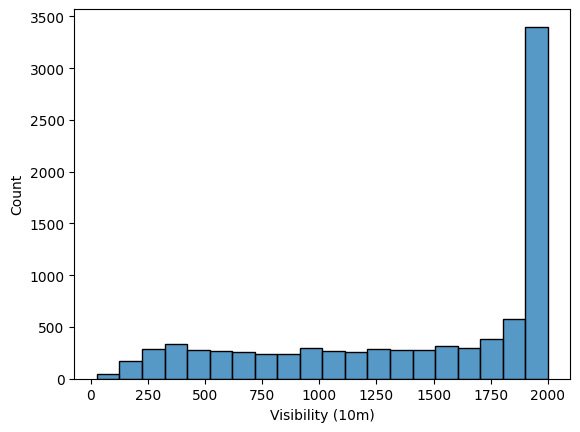

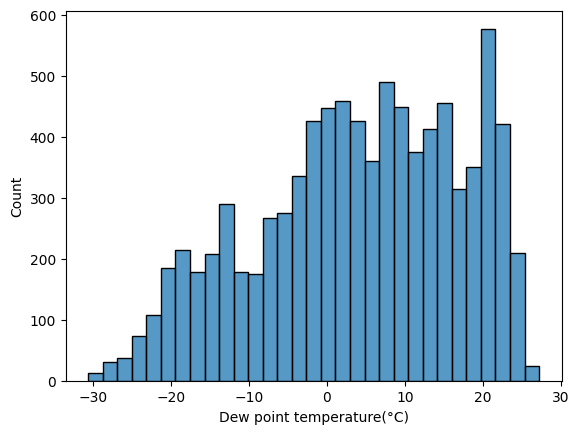

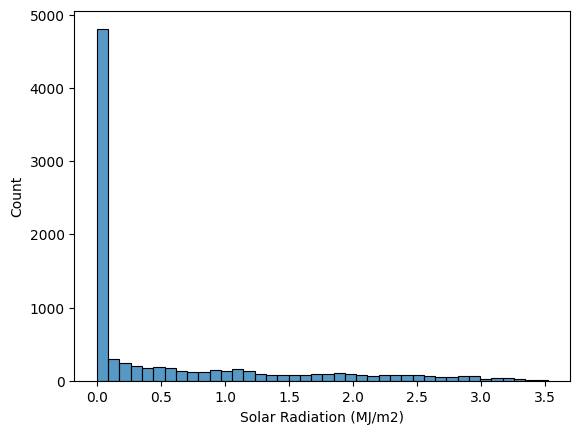

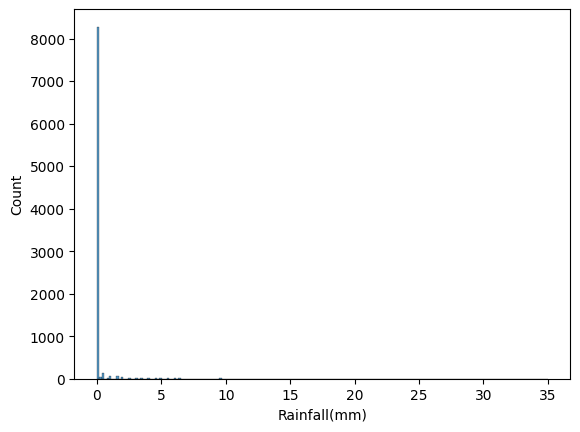

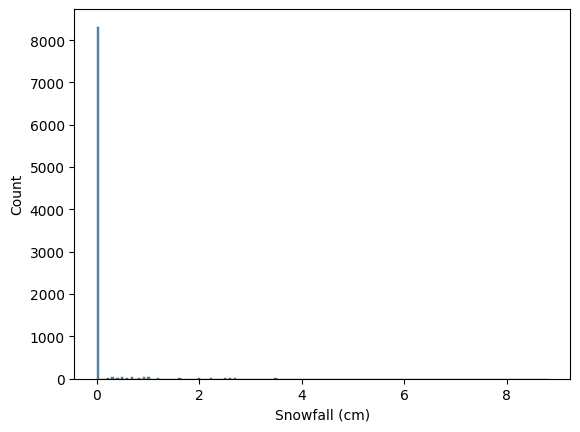

In [13]:
for i in df.select_dtypes(include="number").columns:
    sns.histplot(data=df,x=i)
    plt.show()

- Rented Bike Count and weather condition features (snowfall, rainfall, windspeed) seems to be right skewed
- Visibility and dew point seem to be left skewed
- Hour seems to be trimodal
- Every other feature seems to follow a normal distribution

### Correlation Matrix

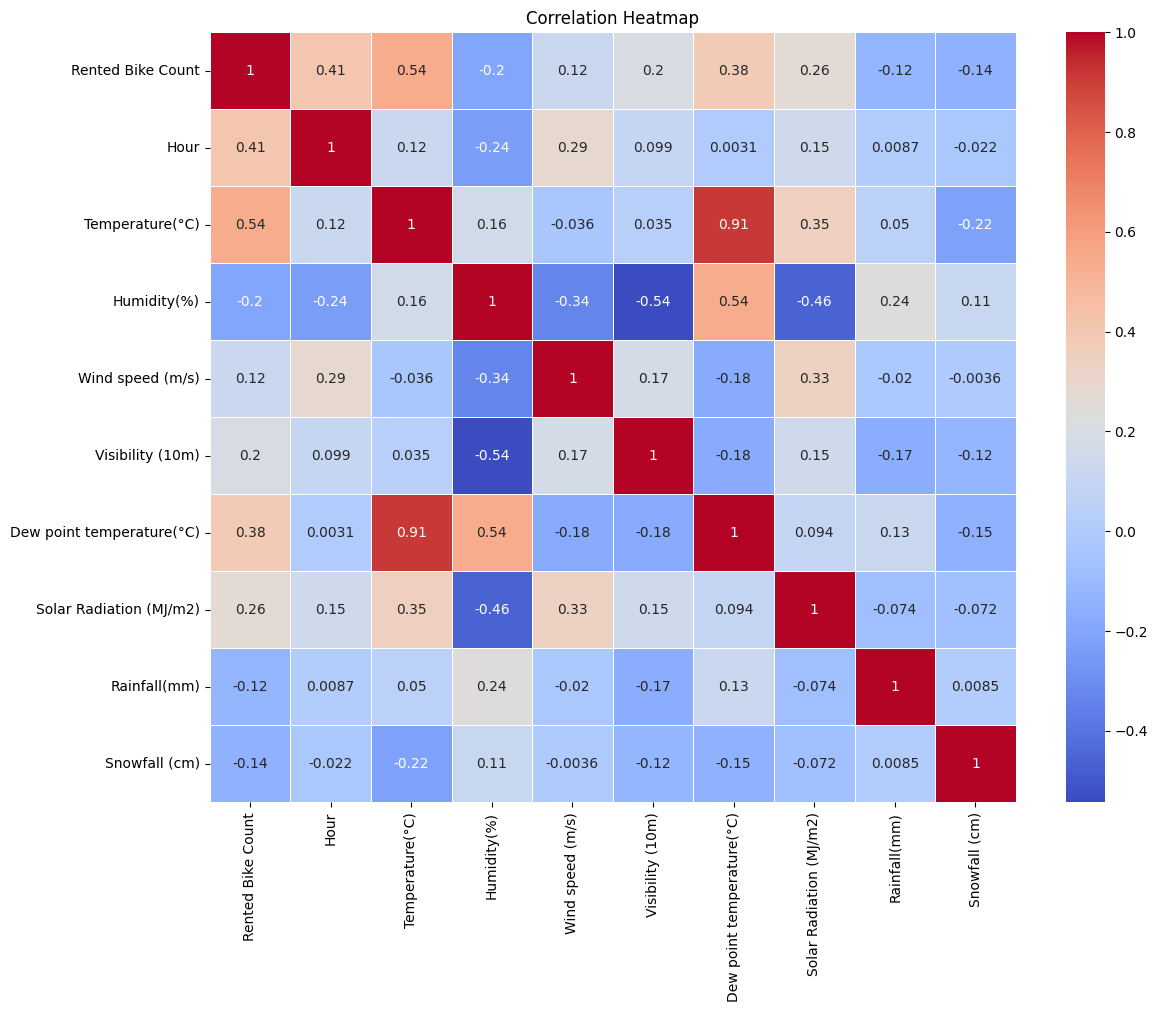

In [14]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(13, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

- temperature seems to be the most correlated with bike count
- dew point and solar radiation are positively correlated
- rainfall, snowfall, and humidity are negatively correlated
- dew point and temperature are highly correlated with each other

### Rented Bike Count vs Weather Features

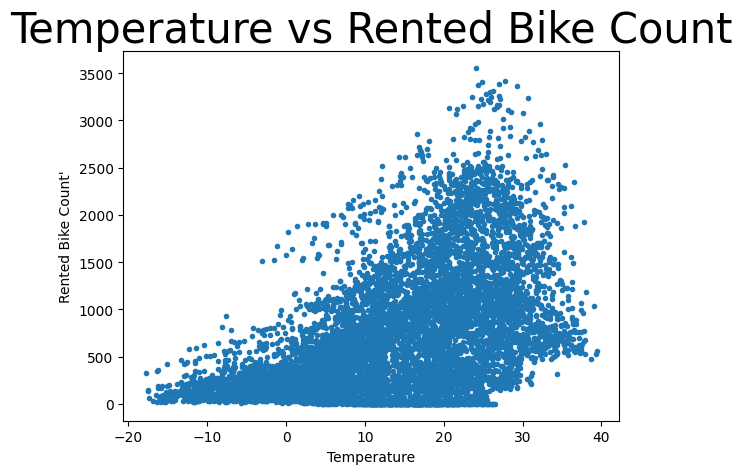

In [15]:
plt.scatter(df['Temperature(°C)'],df['Rented Bike Count'], marker=".")
plt.title("Temperature vs Rented Bike Count", fontsize=30) # set title of graph, fontsize is how big the text will be, fontname is type of font
plt.xlabel("Temperature") # set name of x axis
plt.ylabel("Rented Bike Count'") # set name of y axis
plt.show()

- postive correlation between bike count and temperature
- around 25 degrees celsius is a popular temperature for bike rentals

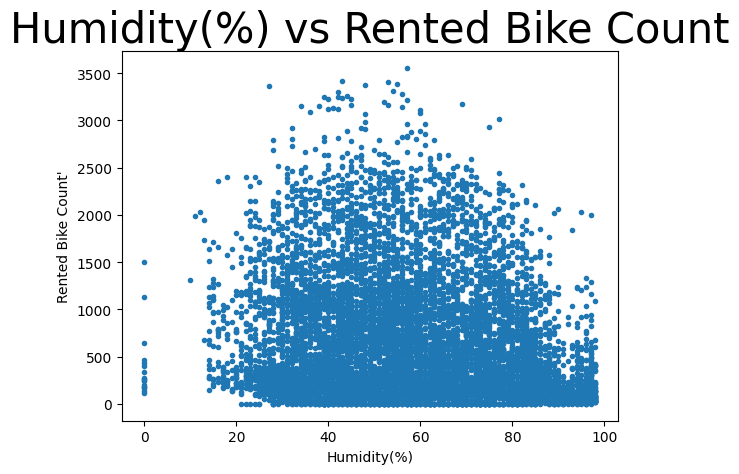

In [16]:
plt.scatter(df['Humidity(%)'],df['Rented Bike Count'], marker=".")
plt.title("Humidity(%) vs Rented Bike Count", fontsize=30) # set title of graph, fontsize is how big the text will be, fontname is type of font
plt.xlabel("Humidity(%)") # set name of x axis
plt.ylabel("Rented Bike Count'") # set name of y axis
plt.show()

- Seems to follow a normal distribution

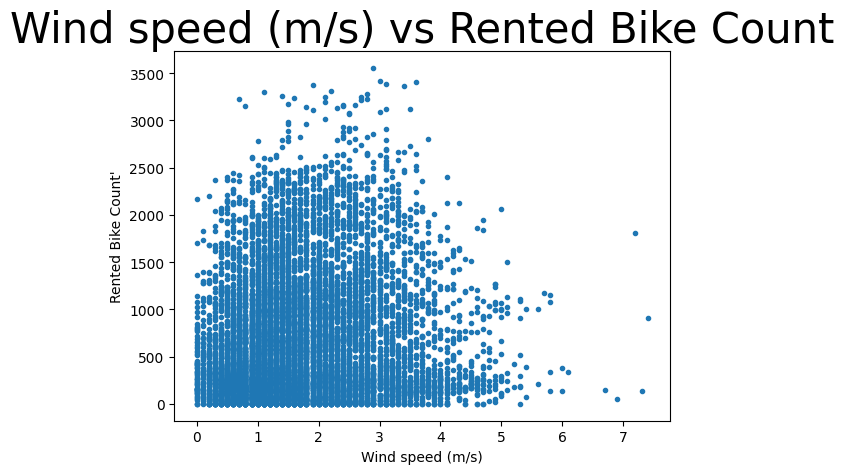

In [17]:
plt.scatter(df['Wind speed (m/s)'],df['Rented Bike Count'], marker=".")
plt.title("Wind speed (m/s) vs Rented Bike Count", fontsize=30) # set title of graph, fontsize is how big the text will be, fontname is type of font
plt.xlabel("Wind speed (m/s)") # set name of x axis
plt.ylabel("Rented Bike Count'") # set name of y axis
plt.show()

- Seems to follow a normal distribution
- Slight skewed right due to outliers

### Rented Bike Count vs Season

In [18]:
df_seasons=df[['Seasons','Rented Bike Count']]
season_count=df_seasons.groupby(['Seasons'], as_index=False)['Rented Bike Count'].mean()

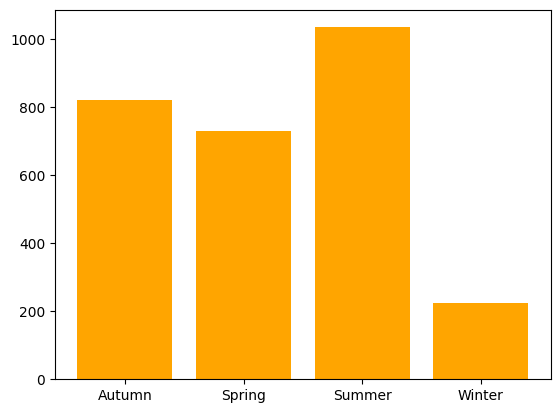

In [19]:
plt.bar(season_count['Seasons'],season_count['Rented Bike Count'], color='orange')
plt.show()

- summer is the most popular season for bike rental
- winter is the least popular season for bike rental
- this could be related to temperature

### Rented Bike Count vs Month

In [20]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["Month"] = df["Date"].dt.month

In [21]:
monthly_avg = (
    df.groupby("Month")["Rented Bike Count"]
    .mean()
    .reset_index()
)

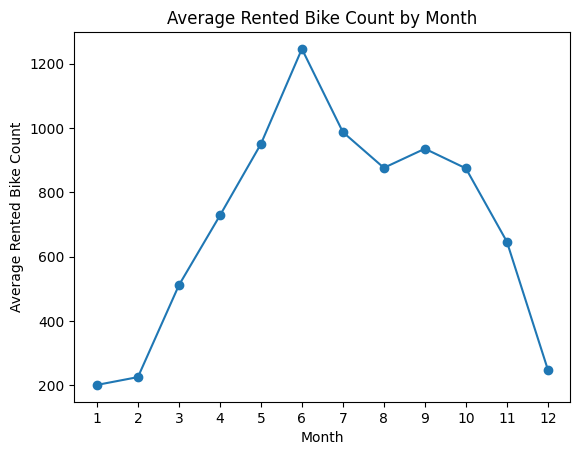

In [22]:
plt.figure()
plt.plot(
    monthly_avg["Month"],
    monthly_avg["Rented Bike Count"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Rented Bike Count")
plt.title("Average Rented Bike Count by Month")

plt.xticks(range(1, 13))
plt.show()

- confirms earlier observation of most popular season for bike rental
- June seems to be the most popular month for rentals

### Rented Bike Count vs Hour

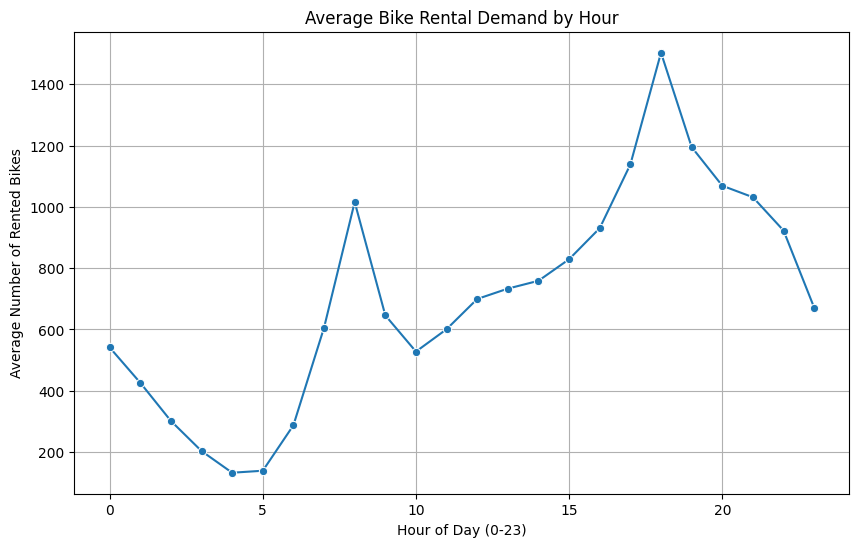

In [23]:
# Group by Hour and calculate the average bike count
hourly_avg = df.groupby('Hour')['Rented Bike Count'].mean().reset_index()

# Set up the plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_avg, x='Hour', y='Rented Bike Count', marker='o')

# Add titles and labels
plt.title('Average Bike Rental Demand by Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Number of Rented Bikes')
plt.grid(True)
plt.show()

- Two peaks around 8:00 and 18:00
- Shows people are more likely to rent early morning or evening